# EpiAI 完整流程教程

> 从数据加载到生产部署的端到端示例。留出最后 12 个月的真实数据
> 作为部署模拟数据，直观展示「训练 → 部署 → 逐月 feed → 对比验证」。

---

## 1. 环境准备

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from EpiAI.models import sklearn_models, ts_models
from EpiAI.models import torch_models          # 需要 PyTorch

from EpiAI.dataset import (
    ForecastPipeline, CsvLoader, TimeSplit, Compose,
    StandardScaler, Log1pTransform, DateFeatures,
    FeatureLag, SlidingWindow,
)
from EpiAI.models.registry import get, list_models
from EpiAI.trainer import EpiAITrainer
from EpiAI.inference import InferencePipeline, ModelVault, DeploymentRuntime

print(f"已注册模型: {len(list_models())}")

已注册模型: 29


---

## 2. 数据加载与拆留

留出最后 12 个月作为部署验证数据，前面的用于训练。

登革热: 195 个月 (2010-01-31 ~ 2026-03-01)
病例数: 最小=0, 最大=28796, 均值=687

训练数据: 183 个月 (2010-01-31 ~ 2025-03-01)
部署数据: 12 个月 (2025-04-01 ~ 2026-03-01)  ← 留出的验证集


/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPytho

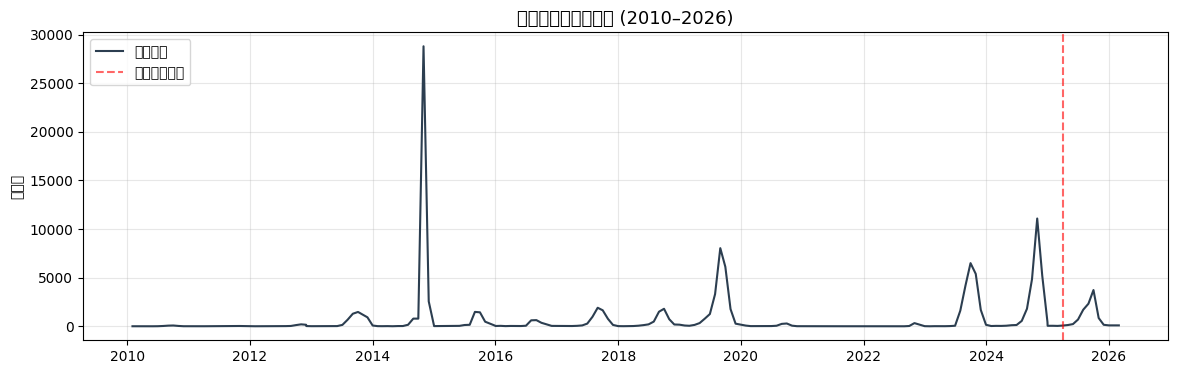

In [2]:
CSV = "../data/Infective_disease_china-V3.csv"
df_raw = pd.read_csv(CSV)

# 筛选登革热
df = df_raw[df_raw["Diseases"] == "登革热 Dengue fever"].copy()
df = df.rename(columns={"Year/Month": "time", "Case number": "cases"})
df = df[["time", "cases"]].reset_index(drop=True)
df["time"] = pd.to_datetime(df["time"])
df["cases"] = df["cases"].astype(float)

print(f"登革热: {len(df)} 个月 ({df['time'].min().date()} ~ {df['time'].max().date()})")
print(f"病例数: 最小={df['cases'].min():.0f}, 最大={df['cases'].max():.0f}, "
      f"均值={df['cases'].mean():.0f}")

# ── 留出最后 12 个月作为部署模拟数据 ──
N_HELD_OUT = 12
df_train = df.iloc[:-N_HELD_OUT].copy()     # 用于训练
df_deploy = df.iloc[-N_HELD_OUT:].copy()    # 用于部署验证

print(f"\n训练数据: {len(df_train)} 个月 ({df_train['time'].min().date()} ~ {df_train['time'].max().date()})")
print(f"部署数据: {len(df_deploy)} 个月 ({df_deploy['time'].min().date()} ~ {df_deploy['time'].max().date()})  ← 留出的验证集")

plt.figure(figsize=(14, 4))
plt.plot(df["time"], df["cases"], color="#2c3e50", label="全部数据")
plt.axvline(x=df_deploy["time"].iloc[0], color="red", linestyle="--", alpha=0.6, label="部署验证开始")
plt.title("全国登革热月发病数 (2010–2026)", fontsize=13)
plt.ylabel("病例数"); plt.legend(); plt.grid(alpha=0.3); plt.show()

---

## 3. 数据管道

In [3]:
df_train.to_csv("/tmp/dengue_train.csv", index=False)

bundle = ForecastPipeline(
    loader=CsvLoader(time_col="time", target_cols="cases",
                     feature_cols="cases"),
    split=TimeSplit(train_ratio=0.7, val_ratio=0.15),
    transforms=None,
    window=SlidingWindow(lookback=12, horizon=3),
).run("/tmp/dengue_train.csv")

print(f"训练窗口: {bundle.train_x.shape}  验证: {bundle.val_x.shape}  测试: {bundle.test_x.shape}")
print(f"lookback={bundle.lookback}, horizon={bundle.horizon}, features={bundle.n_features}")

训练窗口: (114, 12, 1)  验证: (27, 12, 1)  测试: (28, 12, 1)
lookback=12, horizon=3, features=1


---

## 4. 模型训练

### 4.1 深度学习（Torch）

In [4]:
results = {}

for name in ["MLP", "LSTM", "CNN"]:
    try:
        model = get(name)(input_dim=bundle.n_features, lookback=12,
                          horizon=3, target_dim=1)
        result = EpiAITrainer(model=model, verbose=False,
                              optimizer_config={"max_epochs": 10}).fit(bundle)
        results[name] = result
        m = result.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  R²={m['R2']:.3f}")
    except Exception as e:
        print(f"  ❌ {name:10s}  {str(e)[:50]}")

  ✅ MLP         MAE=1520  R²=-0.247
  ✅ LSTM        MAE=1587  R²=-0.351
  ✅ CNN         MAE=1560  R²=-0.324


### 4.2 机器学习（Sklearn）

In [5]:
for name, kwargs in [
    ("RF",  {"n_estimators": 200, "max_depth": 10, "random_state": 42}),
    ("XGB", {"n_estimators": 200, "random_state": 42}),
    ("SVR", {"kernel": "rbf", "C": 1.0}),
]:
    try:
        param_key = {"RF": "rf_params", "XGB": "xgb_params", "SVR": "svm_params"}[name]
        model = get(name)(input_dim=bundle.n_features, lookback=12,
                          horizon=3, target_dim=1, **{param_key: kwargs})
        result = EpiAITrainer(model=model, verbose=False).fit(bundle)
        results[name] = result
        m = result.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  R²={m['R2']:.3f}")
    except Exception as e:
        print(f"  ❌ {name:10s}  {str(e)[:50]}")

  ✅ RF          MAE=980  R²=0.533
  ✅ XGB         MAE=1670  R²=-0.400
  ✅ SVR         MAE=1562  R²=-0.333


### 4.3 时间序列（TimeSeries）

In [6]:
for name, kwargs in [
    ("ETS",   {"seasonal_periods": 12, "seasonal": "add", "trend": "add"}),
    ("ARIMA", {"seasonal": True, "m": 12}),
]:
    try:
        model = get(name)(**kwargs)
        result = EpiAITrainer(model=model, verbose=False).fit(bundle)
        results[name] = result
        m = result.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  R²={m['R2']:.3f}")
    except Exception as e:
        print(f"  ❌ {name:10s}  {str(e)[:50]}")

  ✅ ETS         MAE=2240  R²=-0.303
  ✅ ARIMA       MAE=1431  R²=0.162


---

## 5. ModelVault：模型入库与对比

In [7]:
vault = ModelVault.from_results(results, bundle)
vault.save("/tmp/dengue_vault/")

print("\n模型对比总表（按 R² 排序）：")
print(vault.summary().to_string())

best_name = vault.best("R2")
print(f"\n最佳模型: {best_name}")


模型对比总表（按 R² 排序）：
      paradigm          MAE         RMSE          MAPE        R2  PearsonR   n
model                                                                         
RF     sklearn   980.375183  1829.462036    184.881020  0.533218  0.828794  28
ARIMA       ts  1430.529175  2458.799072   3101.854324  0.161712  0.579201  28
MLP      torch  1520.163818  2990.424805    147.250748 -0.247191  0.373412  28
ETS         ts  2240.397705  3065.627197  15914.701843 -0.303124 -0.313119  28
CNN      torch  1559.641235  3081.198730    108.065474 -0.324056  0.337881  28
SVR    sklearn  1561.999756  3091.794434    245.161963 -0.333178  0.598915  28
LSTM     torch  1586.878540  3112.708252     97.035110 -0.351275 -0.462388  28
XGB    sklearn  1670.188232  3168.889648    191.367829 -0.400494  0.199917  28

最佳模型: RF


---

## 6. 可视化：历史与预测

/tmp/ipykernel_2481657/2804986764.py:24: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.tight_layout()
/tmp/ipykernel_2481657/2804986764.py:24: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.tight_layout()
/tmp/ipykernel_2481657/2804986764.py:24: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.tight_layout()
/tmp/ipykernel_2481657/2804986764.py:24: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.tight_layout()
/tmp/ipykernel_2481657/2804986764.py:24: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.tight_layout()
/tmp/ipykernel_2481657/2804986764.py:24: UserWarning: Glyph 30331 (\N{CJK UNIFIED IDEOGRAPH-767B}) missin

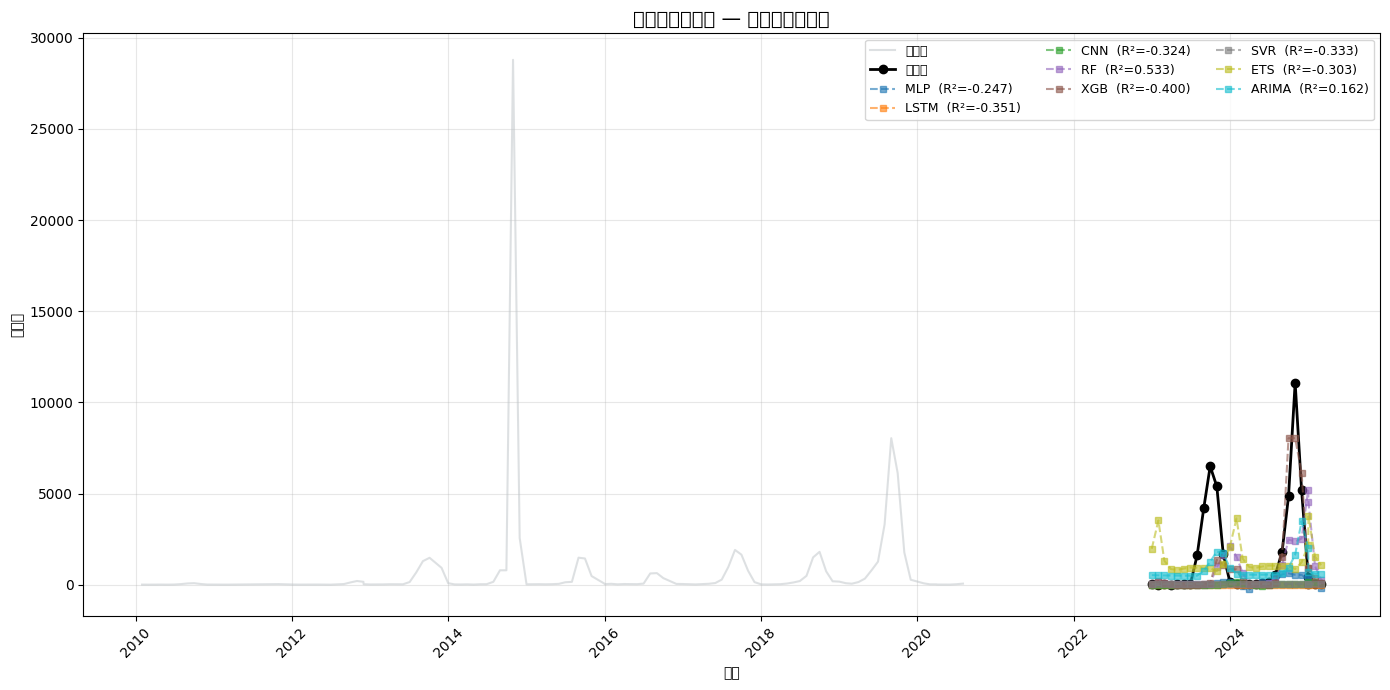

In [8]:
all_time = bundle.train_df["time"].tolist() + bundle.test_df["time"].tolist()
y_all = np.concatenate([bundle.get_y_series("train").ravel(),
                        bundle.get_y_series("test").ravel()])

plt.figure(figsize=(14, 7))
plt.plot(all_time[:len(bundle.train_df)], y_all[:len(bundle.train_df)],
         "-", label="训练集", color="#bdc3c7", alpha=0.5)
test_start = len(bundle.train_df)
test_time = all_time[test_start:]
test_actual = bundle.get_y_series("test").ravel()
plt.plot(test_time, test_actual, "o-", label="实际值", color="black", linewidth=2)

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors):
    preds = r.predictions[:, 0, 0]
    n = len(preds)
    m = r.metrics.iloc[0]
    plt.plot(test_time[:n], preds, "s--", label=f"{name}  (R²={m['R2']:.3f})",
             color=color, alpha=0.6, markersize=4)

plt.legend(fontsize=9, ncol=3)
plt.title("登革热月发病数 — 多模型预测对比", fontsize=14)
plt.ylabel("病例数"); plt.xlabel("时间"); plt.grid(alpha=0.3)
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("/tmp/dengue_all_models.png", dpi=150)
plt.show()

---

## 7. 生产部署模拟

用留出的 12 个月真实数据模拟生产环境逐月 feed。
初始化时，将训练数据全部加载到 `data_table` 中，这样窗口模型和时序模型都有完整的历史可查。

In [9]:
runtime = DeploymentRuntime(
    vault=vault,
    time_col="time",
    time_unit="MS",
    strict=True,
)
# 将全部训练数据载入 data_table（含 transforms=None 时的原始值）
runtime.data_table = df_train.copy()
runtime._train_end_time = df_train["time"].iloc[-1]
print(f"训练数据: {len(runtime.data_table)} 行")
print(f"训练结束: {runtime._train_end_time.date()}")
print(f"部署开始: {df_deploy['time'].iloc[0].date()}")
print(f"窗口模型需要: {bundle.lookback} 行历史 ✅ data_table 已满足")

# ── 初始预测（基于训练数据，预测部署期的第一个月） ──
prev_preds = {}
print("\n初始预测（基于训练数据）：")
for name, inferer in vault.models.items():
    if inferer.paradigm == "ts":
        raw = inferer.forecast(1)
        prev_preds[name] = float(np.asarray(raw).ravel()[0])
    else:
        x_df = df_train.tail(inferer.lookback)[inferer.feature_names]
        raw = inferer.predict(x_df)
        prev_preds[name] = float(raw[0, 0, 0])
    target_month = df_deploy.iloc[0]["time"].strftime("%Y-%m")
    print(f"  {name}: 预测{target_month}={prev_preds[name]:.0f}")

# ── 逐月 feed 留出的真实数据 ──
history = []

for i in range(len(df_deploy)):
    row = df_deploy.iloc[i]
    month_label = row["time"].strftime("%Y-%m")
    actual = int(row["cases"])

    # 记录：本月实际值 vs 上期预测
    record = {"month": month_label, "actual": actual}
    for name in prev_preds:
        record[name] = prev_preds[name]
    history.append(record)

    # 打印
    print(f"  {month_label}: 实报={actual:5d}", end="")
    for name in prev_preds:
        print(f"  {name}预测={prev_preds[name]:6.0f}", end="")
    print()

    # feed 本月数据 → 更新 prev_preds（预测下月）
    new_data = pd.DataFrame({
        "time": [row["time"].strftime("%Y-%m-%d")],
        "cases": [row["cases"]],
    })
    result = runtime.feed(new_data)
    for name, r in result.items():
        if "error" not in r:
            prev_preds[name] = r["pred"][0]  # 预测的下个月的值

print(f"\n模拟完成: {len(df_deploy)} 个月, data_table={len(runtime.data_table)} 行")

训练数据: 183 行
训练结束: 2025-03-01
部署开始: 2025-04-01
窗口模型需要: 12 行历史 ✅ data_table 已满足

初始预测（基于训练数据）：
  MLP: 预测2025-04=209
  LSTM: 预测2025-04=4
  CNN: 预测2025-04=-90
  RF: 预测2025-04=83
  XGB: 预测2025-04=37
  SVR: 预测2025-04=39
  ETS: 预测2025-04=1964
  ARIMA: 预测2025-04=586
  2025-04: 实报=   74  MLP预测=   209  LSTM预测=     4  CNN预测=   -90  RF预测=    83  XGB预测=    37  SVR预测=    39  ETS预测=  1964  ARIMA预测=   586
  2025-05: 实报=  126  MLP预测=   -34  LSTM预测=     3  CNN预测=    34  RF预测=   203  XGB预测=    65  SVR预测=    40  ETS预测=  1964  ARIMA预测=   586
  2025-06: 实报=  225  MLP预测=   189  LSTM预测=     3  CNN预测=    57  RF预测=   561  XGB预测=   144  SVR预测=    40  ETS预测=  3519  ARIMA预测=   734
  2025-07: 实报=  694  MLP预测=   914  LSTM预测=     3  CNN预测=    78  RF预测=  1222  XGB预测=  1978  SVR预测=    42  ETS预测=  1310  ARIMA预测=   774
  2025-08: 实报= 1702  MLP预测=   693  LSTM预测=     3  CNN预测=    24  RF预测=  2622  XGB预测=  8036  SVR预测=    43  ETS预测=   847  ARIMA预测=   785
  2025-09: 实报= 2321  MLP预测=   800  LSTM预测=     3  CNN预测=    60  RF预测=  

### 7.1 部署预测 vs 实际值对比图

/tmp/ipykernel_2481657/3042673182.py:17: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2481657/3042673182.py:17: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2481657/3042673182.py:17: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2481657/3042673182.py:17: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2481657/3042673182.py:17: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2481657/3042673182.py:17: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2481657/3042673182.py:17: UserWarning: Glyph 32626 (\N{CJK UN

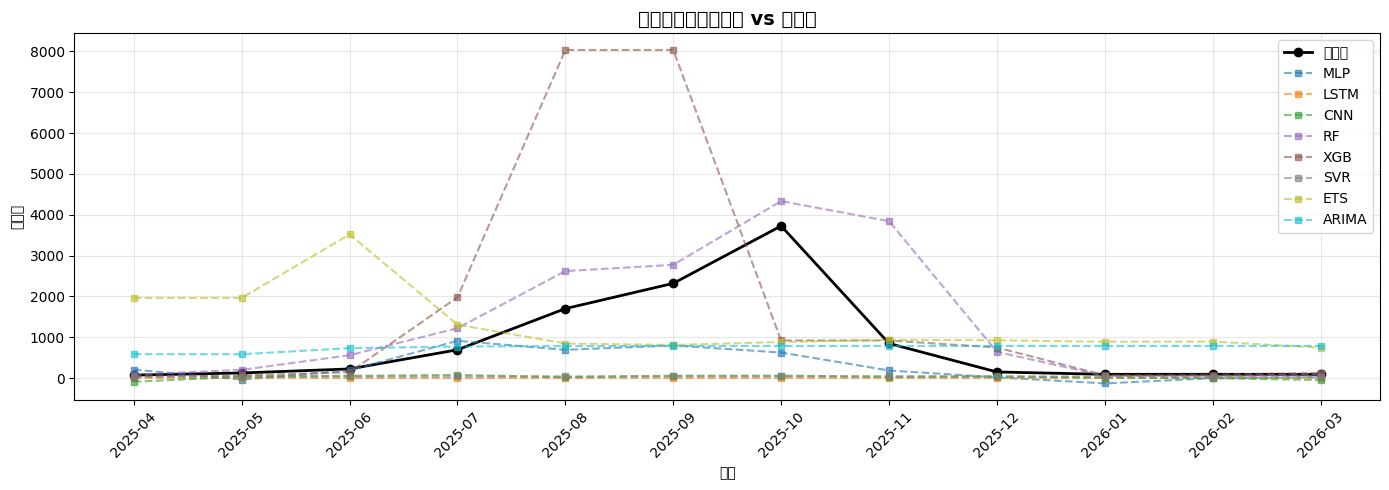

In [10]:
df_hist = pd.DataFrame(history)

plt.figure(figsize=(14, 5))
plt.plot(range(len(df_hist)), df_hist["actual"], "o-", color="black",
         linewidth=2, label="实际值", markersize=6)

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors):
    if name in df_hist.columns:
        plt.plot(range(len(df_hist)), df_hist[name], "s--", label=name,
                 color=color, alpha=0.6, markersize=4)

plt.xticks(range(len(df_hist)), df_hist["month"], rotation=45)
plt.ylabel("病例数"); plt.xlabel("月份")
plt.title("部署模拟：逐月预测 vs 实际值", fontsize=14, fontweight="bold")
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/dengue_deploy_sim.png", dpi=150)
plt.show()

### 7.2 保存运行时

In [11]:
runtime.save("/tmp/dengue_runtime/")
print("\n运行时已保存到 /tmp/dengue_runtime/")

# 保存 vault
vault.save("/tmp/dengue_vault/")
print("模型 vault 已保存到 /tmp/dengue_vault/")

ArrowTypeError: ("object of type <class 'str'> cannot be converted to int", 'Conversion failed for column time with type object')

---

## 8. 附录

In [ ]:
print("可用模型:")
print(f"  Torch:   {list_models('torch')}")
print(f"  Sklearn: {list_models('sklearn')}")
print(f"  TimeSeries: {list_models('ts')}")

依赖安装：

In [ ]:
%%bash
pip install -e .                                # 基础
pip install torch                               # 深度学习
pip install -e ".[xgb,lgbm]"                   # 额外机器学习
pip install -e ".[all]"                        # 全部